# Evaluación en Tiempo Real: Optimización Uni-Objetivo con GA y MLP sobre Datos Reales



En este cuaderno ejecutamos el algoritmo genético uni-objetivo (MLP + GA) **en tiempo real** sobre cada instancia del conjunto de test, simulando exactamente lo que haría el sistema en producción.



**A diferencia del cuaderno de optimización en malla** (donde se pre-calculó una Lookup Table sobre una malla regular), aquí el algoritmo genético se ejecuta **individualmente para cada fila del test**, tomando las condiciones reales de planta ($T_{in\_leche}$, $\Delta P$, $t_{ciclo}$) y optimizando las variables de decisión ($F_{flow}^*$, $T_{servicio}^*$).



## Objetivo

Responder a la pregunta de negocio: **¿Cuánta energía habríamos ahorrado si esta IA hubiera controlado la fábrica en tiempo real?**



## Flujo de Trabajo

1. Cargar el modelo MLP entrenado (gemelo digital) y los datos reales de test.

2. Para **cada instancia real**, ejecutar GA uni-objetivo para encontrar los setpoints óptimos $(F_{flow}^*, T_{servicio}^*)$ que minimicen el consumo específico $E/F$ manteniendo $T_{out} \geq 72.3°C$.

3. Comparar punto a punto la operación histórica vs la recomendación de la IA.

4. Cuantificar los KPIs de ahorro energético, eficiencia y seguridad alimentaria.



## KPIs Evaluados

| KPI | Descripción |

| Ahorro energético | $\Delta E = E_{hist} - E_{IA}$ (kW) |

| Mejora eficiencia | $\frac{E_{hist}}{F_{hist}} - \frac{E_{IA}}{F_{IA}}$ (kW/(L/h)) |

| Producción | Comparativa $F_{flow}$ hist vs IA |

| Seguridad | $\% \ T_{out}^{IA} \geq 72.3°C$ |

In [1]:
# ==========================================
# 1. IMPORTACIONES
# ==========================================
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import random
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
from deap import base, creator, tools, algorithms
from tqdm.notebook import tqdm

In [2]:
# ==========================================
# 2. CARGA DEL MODELO MLP Y DATOS DE TEST
# ==========================================
ARTIFACTS_DIR = "../../models/artifacts"

# --- 2.1 Configuración del modelo ---
with open(f"{ARTIFACTS_DIR}/model_config.json", "r") as f:
    config = json.load(f)

INPUT_SIZE = config["input_size"]
OUTPUT_SIZE = config["output_size"]
NUM_LAYERS = config["num_layers"]
NEURONS = config["neurons"]
ACTIVATION = config["activation"]
FEATURES_ORDER = config["features_in_order"]
TARGETS_ORDER = config["targets_in_order"]

print(f"✅ Configuración: MLP {INPUT_SIZE} → {NUM_LAYERS}×{NEURONS} → {OUTPUT_SIZE}")
print(f"   Features: {FEATURES_ORDER}")
print(f"   Targets:  {TARGETS_ORDER}")

# --- 2.2 Reconstruir e instanciar modelo ---
class DynamicMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()
        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = DynamicMLP(INPUT_SIZE, OUTPUT_SIZE, NUM_LAYERS, NEURONS, ACTIVATION)
model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_predictor.pt"))
model.eval()
print("✅ Modelo MLP cargado y en modo evaluación.")

# --- 2.3 Escaladores ---
scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
print("✅ Escaladores (X, y) cargados.")

# --- 2.4 Datos de test ---
DATA_PATH = "../../data/splits/test.csv"
df_test = pd.read_csv(DATA_PATH)
print(f"\n📊 Datos de test cargados: {len(df_test):,} instancias reales")
print(f"   Columnas: {list(df_test.columns)}")
display(df_test.describe().round(2))

✅ Configuración: MLP 5 → 3×64 → 2
   Features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
   Targets:  ['E_consumo', 'T_out_leche']
✅ Modelo MLP cargado y en modo evaluación.


C:\Users\vgarc\AppData\Local\Temp\ipykernel_16252\1101444713.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_pred

✅ Escaladores (X, y) cargados.

📊 Datos de test cargados: 7,708 instancias reales
   Columnas: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P', 'E_consumo', 'T_out_leche']


,T_in_leche,F_flow,T_servicio,t_ciclo,Delta_P,E_consumo,T_out_leche
count,7708.00,7708.00,7708.00,7708.00,7708.00,7708.00,7708.00
mean,4.00,4920.61,81.55,274.04,0.60,435.40,72.60
std,2.15,332.14,1.17,157.45,0.10,36.19,0.08
min,0.03,3584.44,78.14,5.00,0.31,312.80,72.18
25%,2.23,4700.83,80.70,135.00,0.54,410.94,72.56
50%,4.00,4942.61,81.55,275.00,0.60,433.37,72.60
75%,5.59,5176.24,82.37,410.00,0.67,459.33,72.63
max,7.95,5498.89,85.07,545.00,0.91,544.43,73.50


In [3]:
# ==========================================
# 3. DEFINICIÓN DEL GA: PREDICCIÓN, FITNESS UNI-OBJETIVO Y TOOLBOX
# ==========================================

# --- Límites del espacio de búsqueda ---
BOUNDS = {
    'F_flow':     (3500.0, 5500.0),   # L/h
    'T_servicio': (76.0,   95.0),     # °C
}

# Margen de seguridad termodinámico + tolerancia de instrumentación:
# Limit legal: 72.0°C. Setpoint: 72.3°C (+0.3°C para absorber incertidumbre
# del sensor PT100 Clase A ±0.3°C segun IEC 60751 y tolerancia PMO-FDA ±0.5°F)
T_OUT_MIN = 72.3       # Restricción de seguridad alimentaria con margen PT100/PMO-FDA
PENALTY_FACTOR = 10.0  # Factor de penalización por déficit de T_out

# --- Parámetros GA v4 (uni-objetivo, los mismos que en optimization_ga_v4) ---
GA_OPT = {
    'pop_size': 150,
    'n_gen': 15,
    'cxpb': 0.8,
    'mutpb': 0.2,
}


def predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P):
    """Consulta al MLP y devuelve (E_consumo, T_out_leche) en unidades reales."""
    x_raw = np.array([[T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]])
    x_scaled = scaler_X.transform(x_raw)
    x_tensor = torch.FloatTensor(x_scaled)
    with torch.no_grad():
        y_scaled = model(x_tensor).numpy()
    y_real = scaler_y.inverse_transform(y_scaled)[0]
    return y_real[0], y_real[1]   # E_consumo, T_out_leche


def fitness_consumo_especifico(individual, T_in_leche, t_ciclo, Delta_P):
    """
    Fitness uni-objetivo: min E_consumo / F_flow.
    Restricción T_out >= 72.3°C vía penalización proporcional.
    """
    F_flow, T_servicio = individual
    E_consumo, T_out = predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P)

    if T_out < T_OUT_MIN:
        deficit = T_OUT_MIN - T_out
        penalty = 1.0 + PENALTY_FACTOR * deficit
        penalized_value = 10000.0 + (float(E_consumo) / max(float(F_flow), 1.0)) * penalty
        return (penalized_value,)

    consumo_especifico = float(E_consumo) / max(float(F_flow), 1.0)
    return (consumo_especifico,)


# --- Configuración DEAP ---
for cls_name in ["FitnessMin_v4", "Individual_v4"]:
    if cls_name in creator.__dict__:
        del creator.__dict__[cls_name]

creator.create("FitnessMin_v4", base.Fitness, weights=(-1.0,))
creator.create("Individual_v4", list, fitness=creator.FitnessMin_v4)

toolbox = base.Toolbox()
toolbox.register("attr_F_flow", random.uniform, BOUNDS['F_flow'][0], BOUNDS['F_flow'][1])
toolbox.register("attr_T_servicio", random.uniform, BOUNDS['T_servicio'][0], BOUNDS['T_servicio'][1])
toolbox.register("individual", tools.initCycle, creator.Individual_v4,
                 (toolbox.attr_F_flow, toolbox.attr_T_servicio), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

LOW = [BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]]
UP  = [BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]]

def checkBounds(low, up):
    def decorator(func):
        def wrapper(*args, **kw):
            offspring = func(*args, **kw)
            for child in offspring:
                for i, (lo, hi) in enumerate(zip(low, up)):
                    child[i] = max(lo, min(hi, child[i]))
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mate", checkBounds(LOW, UP))
toolbox.decorate("mutate", checkBounds(LOW, UP))

print("✅ GA configurado: Uni-objetivo (min E_consumo / F_flow)")
print(f"   Espacio: F_flow ∈ {BOUNDS['F_flow']}, T_servicio ∈ {BOUNDS['T_servicio']}")
print(f"   Restricción: T_out ≥ {T_OUT_MIN}°C (penalización × {PENALTY_FACTOR})")
print(f"   Población: {GA_OPT['pop_size']} | Generaciones: {GA_OPT['n_gen']}")
print(f"   Cruce: {GA_OPT['cxpb']} | Mutación: {GA_OPT['mutpb']}")

✅ GA configurado: Uni-objetivo (min E_consumo / F_flow)
   Espacio: F_flow ∈ (3500.0, 5500.0), T_servicio ∈ (76.0, 95.0)
   Restricción: T_out ≥ 72.3°C (penalización × 10.0)
   Población: 150 | Generaciones: 15
   Cruce: 0.8 | Mutación: 0.2


## 4. Ejecución del GA en Tiempo Real sobre cada Instancia de Test



Para cada una de las instancias del conjunto de test, ejecutamos GA uni-objetivo completo:



1. Leemos las condiciones reales de esa fila: $(T_{in\_leche}, \Delta P, t_{ciclo})$.

2. Ejecutamos el GA (150 individuos × 15 generaciones) para encontrar $(F_{flow}^*, T_{servicio}^*)$.

3. Del `HallOfFame(1)`, obtenemos directamente el mejor individuo (menor consumo específico $E/F$).

4. Comparamos con lo que realmente ocurrió históricamente.



Esto simula exactamente lo que haría el sistema en producción: **recibir sensores → optimizar → recomendar setpoints.**

In [4]:
# ==============================================================================
# 4. EJECUCIÓN DEL GA EN TIEMPO REAL SOBRE CADA INSTANCIA DE TEST
# ==============================================================================

MASTER_SEED = 1
resultados = []

print(f"🚀 Optimización en tiempo real: {len(df_test):,} instancias de test")
print(f"   GA: pop={GA_OPT['pop_size']}, gen={GA_OPT['n_gen']}")
print("=" * 70)

t_global = time.time()

pbar = tqdm(range(len(df_test)), total=len(df_test), desc="GA en tiempo real",
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}",
            unit="inst")

for idx in pbar:
    row = df_test.iloc[idx]
    t_in   = float(row['T_in_leche'])
    dp     = float(row['Delta_P'])
    t_ciclo = float(row['t_ciclo'])

    # Semilla reproducible por instancia
    seed = MASTER_SEED + idx
    random.seed(seed)
    np.random.seed(seed)

    # Registrar fitness con las condiciones reales de esta instancia
    toolbox.register("evaluate", fitness_consumo_especifico,
                     T_in_leche=t_in, t_ciclo=t_ciclo, Delta_P=dp)

    # Inicializar y evaluar población
    pop = toolbox.population(n=GA_OPT['pop_size'])
    fitnesses = list(map(toolbox.evaluate, pop))
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit

    # HallOfFame para elitismo
    hof = tools.HallOfFame(1)
    hof.update(pop)

    # Evolución GA uni-objetivo
    for gen in range(GA_OPT['n_gen']):
        offspring = algorithms.varOr(pop, toolbox, lambda_=len(pop),
                                     cxpb=GA_OPT['cxpb'], mutpb=GA_OPT['mutpb'])
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
        pop[:] = toolbox.select(pop + offspring, len(pop))
        hof.update(pop)

    # --- Extraer mejor solución de HallOfFame ---
    best_ind = hof[0]
    F_flow_val, T_servicio_val = best_ind
    E_real, T_out_real = predict_with_model(F_flow_val, T_servicio_val, t_in, t_ciclo, dp)
    e_real = float(E_real)
    t_out_real = float(T_out_real)
    consumo_esp = e_real / max(F_flow_val, 1.0)
    factible = t_out_real >= T_OUT_MIN

    resultados.append({
        # Condiciones reales de la instancia
        'T_in_leche': t_in, 'Delta_P': dp, 't_ciclo': t_ciclo,
        # Histórico real
        'HIST_F_flow': float(row['F_flow']),
        'HIST_T_servicio': float(row['T_servicio']),
        'HIST_E_consumo': float(row['E_consumo']),
        'HIST_T_out': float(row['T_out_leche']),
        # Recomendación IA (GA en tiempo real)
        'IA_F_flow': round(F_flow_val, 2),
        'IA_T_servicio': round(T_servicio_val, 2),
        'IA_E_consumo': round(e_real, 4),
        'IA_T_out': round(t_out_real, 2),
        'IA_consumo_especifico': round(consumo_esp, 6),
        'IA_factible': factible,
        'fitness_final': round(best_ind.fitness.values[0], 6),
    })

    # Progreso cada 500 instancias
    if (idx + 1) % 500 == 0:
        pct_fact = sum(1 for r in resultados if r['IA_factible']) / len(resultados) * 100
        ahorro_parcial = np.mean([r['HIST_E_consumo'] - r['IA_E_consumo'] for r in resultados])
        pbar.set_postfix_str(f"fact={pct_fact:.0f}% | Δ={ahorro_parcial:+.1f}kW")

pbar.close()

# --- Construir DataFrame de evaluación ---
t_total = time.time() - t_global
df_eval = pd.DataFrame(resultados)

# Calcular KPIs comparativos
df_eval['Ahorro_kW'] = df_eval['HIST_E_consumo'] - df_eval['IA_E_consumo']
df_eval['Ahorro_pct'] = (df_eval['Ahorro_kW'] / df_eval['HIST_E_consumo']) * 100
df_eval['HIST_Eficiencia'] = df_eval['HIST_E_consumo'] / df_eval['HIST_F_flow']
df_eval['IA_Eficiencia'] = df_eval['IA_E_consumo'] / df_eval['IA_F_flow']
df_eval['Mejora_Eficiencia'] = df_eval['HIST_Eficiencia'] - df_eval['IA_Eficiencia']
df_eval['Delta_F_flow'] = df_eval['IA_F_flow'] - df_eval['HIST_F_flow']
df_eval['Delta_T_servicio'] = df_eval['IA_T_servicio'] - df_eval['HIST_T_servicio']

n_factibles = df_eval['IA_factible'].sum()
n_total = len(df_eval)

print("\n" + "=" * 70)
print("✅ OPTIMIZACIÓN EN TIEMPO REAL COMPLETADA")
print("=" * 70)
print(f"   Instancias procesadas:  {n_total:,}")
print(f"   Soluciones factibles:   {n_factibles:,} ({n_factibles/n_total*100:.1f}%)")
print(f"   Tiempo total:           {t_total:.1f}s ({t_total/60:.1f} min)")
print(f"   Velocidad media:        {n_total/t_total:.1f} inst/s")
print(f"   Tiempo medio por inst.: {t_total/n_total*1000:.1f} ms")
print(f"   Ahorro medio:           {df_eval['Ahorro_kW'].mean():+.2f} kW ({df_eval['Ahorro_pct'].mean():+.2f}%)")

🚀 Optimización en tiempo real: 7,708 instancias de test
   GA: pop=150, gen=15


GA en tiempo real:   0%|          | 0/7708 [00:00<?, ?inst/s


✅ OPTIMIZACIÓN EN TIEMPO REAL COMPLETADA
   Instancias procesadas:  7,708
   Soluciones factibles:   7,708 (100.0%)
   Tiempo total:           5220.1s (87.0 min)
   Velocidad media:        1.5 inst/s
   Tiempo medio por inst.: 677.2 ms
   Ahorro medio:           +9.14 kW (+1.48%)


## 5. Cuantificación de KPIs: Histórico vs IA en Tiempo Real



Calculamos las métricas clave que demuestran el valor del sistema de optimización uni-objetivo ejecutado en tiempo real frente a la operación histórica.



| KPI | Fórmula | Interpretación |
| :--- | :--- | :--- |
| Ahorro energético medio | $\bar{\Delta E} = \bar{E}_{hist} - \bar{E}_{IA}$ | Reducción media de energía (kWh) |
| Ahorro porcentual | $\frac{\Delta E}{E_{hist}} \times 100$ | % de energía ahorrada |
| Mejora eficiencia específica | $\frac{E_{hist}}{F_{hist}} - \frac{E_{IA}}{F_{IA}}$ | Menos energía por volumen (kWh/L) |
| Cumplimiento de seguridad | % de tiempo con $T_{out}^{IA} \geq 72.3$°C | Garantía alimentaria (Pasteurización) |

In [5]:
# ==========================================
# 5. TABLA DE KPIs PRINCIPALES
# ==========================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# --- KPIs Energéticos ---
ahorro_medio_kw = df_eval['Ahorro_kW'].mean()
ahorro_total_kw = df_eval['Ahorro_kW'].sum()
ahorro_medio_pct = df_eval['Ahorro_pct'].mean()

E_hist_media = df_eval['HIST_E_consumo'].mean()
E_ia_media = df_eval['IA_E_consumo'].mean()

# --- NUEVO: Conversión física a Energía (kWh) ---
# Si las muestras son cada 5 minutos, el tiempo transcurrido por muestra es 5/60 horas
factor_tiempo_h = 5 / 60
ahorro_total_kwh = ahorro_total_kw * factor_tiempo_h

# --- KPIs de Eficiencia Específica ---
eff_hist_media = df_eval['HIST_Eficiencia'].mean()
eff_ia_media = df_eval['IA_Eficiencia'].mean()
mejora_eff_media = df_eval['Mejora_Eficiencia'].mean()
mejora_eff_pct = (mejora_eff_media / eff_hist_media) * 100

# --- KPIs de Producción ---
F_hist_media = df_eval['HIST_F_flow'].mean()
F_ia_media = df_eval['IA_F_flow'].mean()
delta_F_medio = df_eval['Delta_F_flow'].mean()
delta_F_pct = (delta_F_medio / F_hist_media) * 100

# --- KPIs de Seguridad Alimentaria ---
cumplimiento_hist = (df_eval['HIST_T_out'] >= 72.3).mean() * 100
cumplimiento_ia = (df_eval['IA_T_out'] >= 72.3).mean() * 100
T_out_ia_min = df_eval['IA_T_out'].min()
T_out_ia_media = df_eval['IA_T_out'].mean()

# --- KPIs de T_servicio ---
T_serv_hist_media = df_eval['HIST_T_servicio'].mean()
T_serv_ia_media = df_eval['IA_T_servicio'].mean()
delta_T_serv = df_eval['Delta_T_servicio'].mean()

print("=" * 70)
print("📊 CUADRO DE MANDO: HISTÓRICO vs IA (GA UNI-OBJETIVO - TIEMPO REAL)")
print("=" * 70)

# Cambiado el título a Potencia y Energía para ser 100% exactos
print(f"\n⚡ POTENCIA Y ENERGÍA")
print(f"   {'Métrica':<35} {'Histórico':>12} {'IA':>12} {'Delta':>12}")
print(f"   {'-'*35} {'-'*12} {'-'*12} {'-'*12}")
# La media se mantiene en kW (Potencia promedio demandada)
print(f"   {'Potencia media demandada (kW)':<35} {E_hist_media:>12.2f} {E_ia_media:>12.2f} {ahorro_medio_kw:>+12.2f}")
print(f"   {'Ahorro porcentual (%)':<35} {'':>12} {'':>12} {ahorro_medio_pct:>+12.2f}%")
# El ahorro total SÍ es energía (kWh) aplicando el factor de 5 minutos
print(f"   {'Energía total ahorrada (kWh)':<35} {'':>12} {'':>12} {ahorro_total_kwh:>+12.1f}")

print(f"\n📈 EFICIENCIA ESPECÍFICA (kWh/L)")
print(f"   {'E/F medio':<35} {eff_hist_media:>12.6f} {eff_ia_media:>12.6f} {mejora_eff_media:>+12.6f}")
print(f"   {'Mejora eficiencia (%)':<35} {'':>12} {'':>12} {mejora_eff_pct:>+12.2f}%")

print(f"\n🏭 PRODUCCIÓN (L/h)")
print(f"   {'F_flow medio':<35} {F_hist_media:>12.1f} {F_ia_media:>12.1f} {delta_F_medio:>+12.1f}")
print(f"   {'Cambio producción (%)':<35} {'':>12} {'':>12} {delta_F_pct:>+12.2f}%")

print(f"\n🌡️ TEMPERATURA DE SERVICIO (°C)")
print(f"   {'T_servicio medio':<35} {T_serv_hist_media:>12.2f} {T_serv_ia_media:>12.2f} {delta_T_serv:>+12.2f}")

print(f"\n🔒 SEGURIDAD ALIMENTARIA (T_out ≥ 72.3°C)")
print(f"   {'Cumplimiento histórico':<35} {cumplimiento_hist:>12.1f}%")
print(f"   {'Cumplimiento IA':<35} {cumplimiento_ia:>12.1f}%")
print(f"   {'T_out IA mínimo':<35} {T_out_ia_min:>12.2f} °C")
print(f"   {'T_out IA medio':<35} {T_out_ia_media:>12.2f} °C")
print("=" * 70)

📊 CUADRO DE MANDO: HISTÓRICO vs IA (GA UNI-OBJETIVO - TIEMPO REAL)

⚡ POTENCIA Y ENERGÍA
   Métrica                                Histórico           IA        Delta
   ----------------------------------- ------------ ------------ ------------
   Potencia media demandada (kW)             435.40       426.27        +9.14
   Ahorro porcentual (%)                                                +1.48%
   Energía total ahorrada (kWh)                                       +5868.0

📈 EFICIENCIA ESPECÍFICA (kWh/L)
   E/F medio                               0.088448     0.078960    +0.009489
   Mejora eficiencia (%)                                               +10.73%

🏭 PRODUCCIÓN (L/h)
   F_flow medio                              4920.6       5398.8       +478.2
   Cambio producción (%)                                                +9.72%

🌡️ TEMPERATURA DE SERVICIO (°C)
   T_servicio medio                           81.55        81.35        -0.19

🔒 SEGURIDAD ALIMENTARIA (T_out ≥ 72.3°C)


## 6. Visualizaciones Comparativas



Comparación gráfica entre la operación histórica y las recomendaciones de la IA optimizada en tiempo real sobre cada instancia de test.

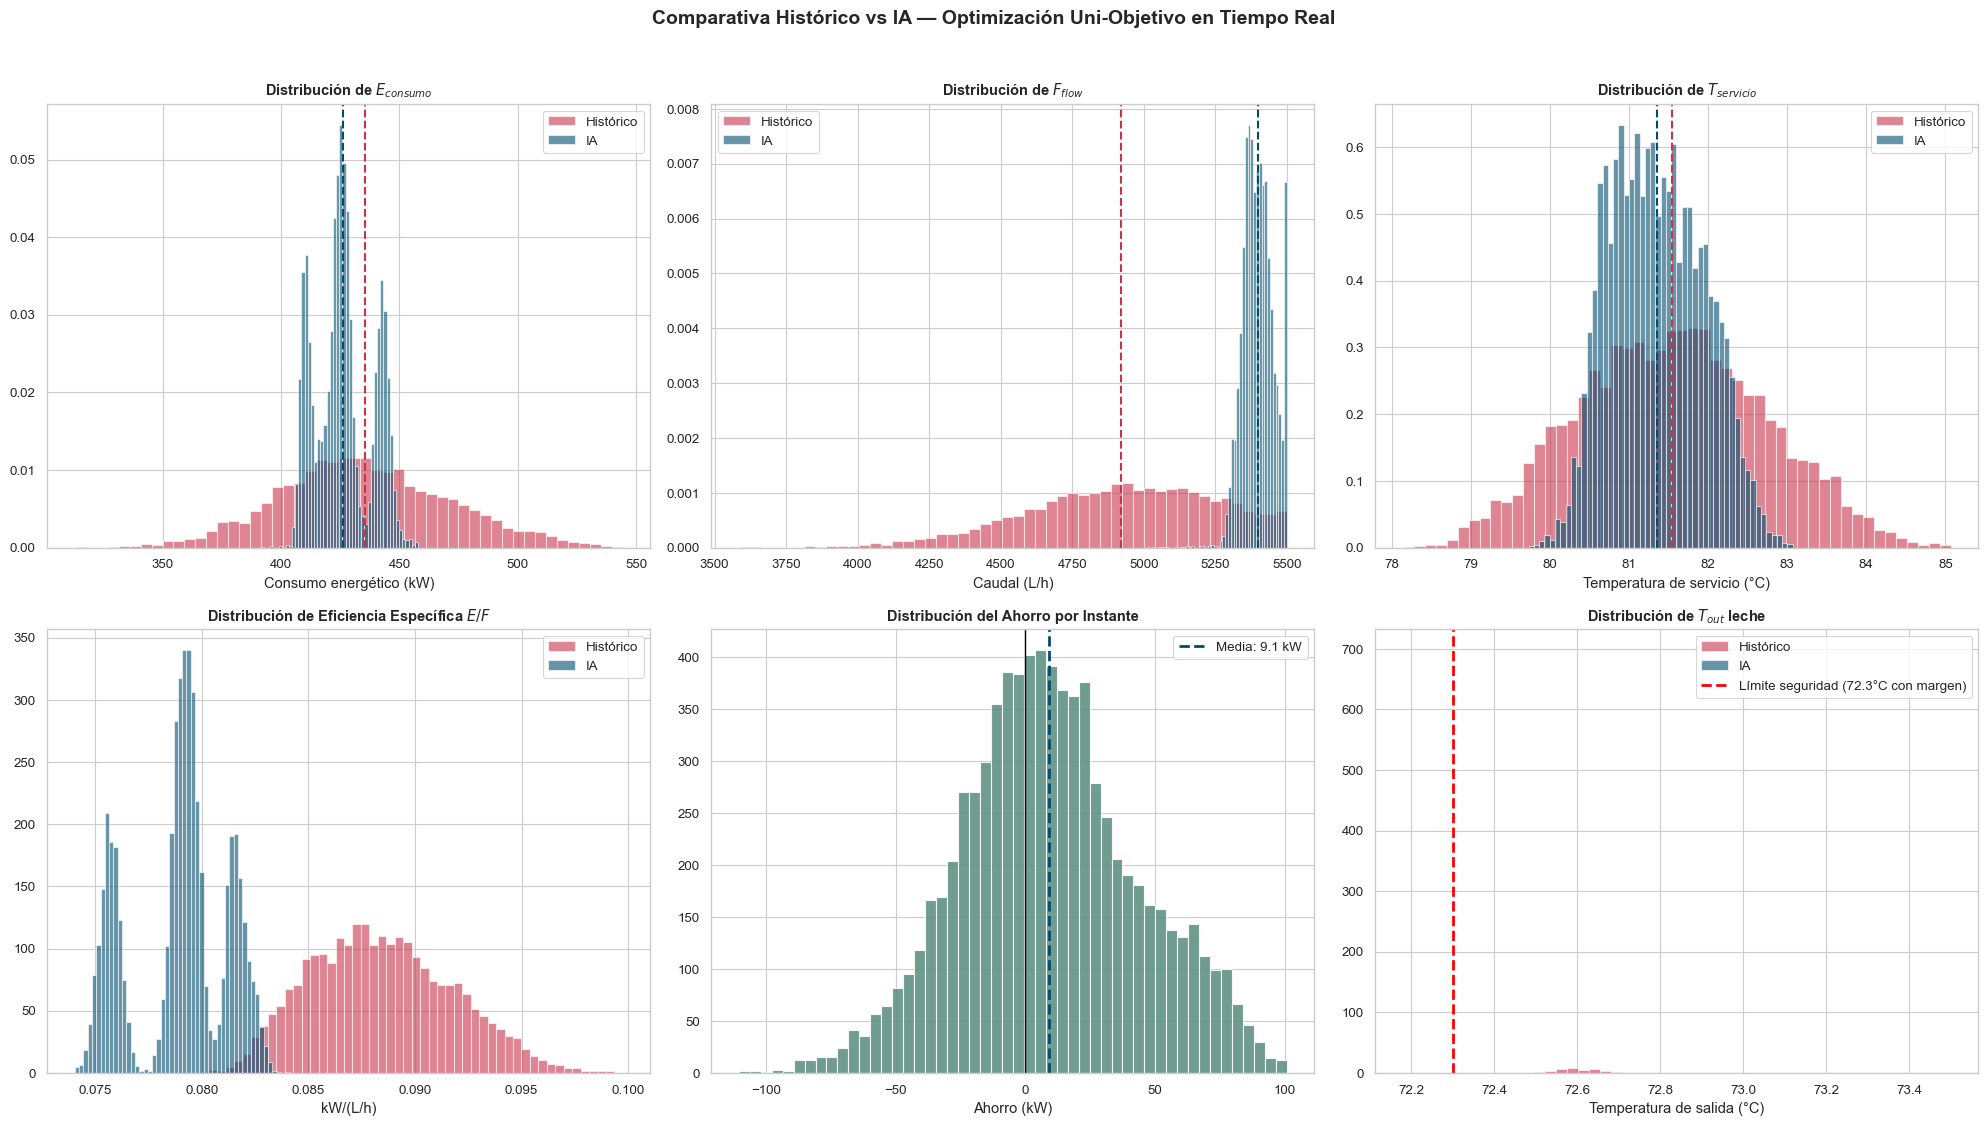

In [6]:
# ==============================================================================
# 6.1 DISTRIBUCIONES COMPARATIVAS: Hist vs IA (tiempo real)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# --- 6.1.1 Consumo energético ---
axes[0, 0].hist(df_eval['HIST_E_consumo'], bins=50, alpha=0.6, color='#c83349', label='Histórico', density=True)
axes[0, 0].hist(df_eval['IA_E_consumo'], bins=50, alpha=0.6, color='#004c6d', label='IA', density=True)
axes[0, 0].axvline(E_hist_media, color='#c83349', linestyle='--', linewidth=1.5)
axes[0, 0].axvline(E_ia_media, color='#004c6d', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Distribución de $E_{consumo}$', fontweight='bold')
axes[0, 0].set_xlabel('Consumo energético (kW)')
axes[0, 0].legend()

# --- 6.1.2 Caudal (Producción) ---
axes[0, 1].hist(df_eval['HIST_F_flow'], bins=50, alpha=0.6, color='#c83349', label='Histórico', density=True)
axes[0, 1].hist(df_eval['IA_F_flow'], bins=50, alpha=0.6, color='#004c6d', label='IA', density=True)
axes[0, 1].axvline(F_hist_media, color='#c83349', linestyle='--', linewidth=1.5)
axes[0, 1].axvline(F_ia_media, color='#004c6d', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('Distribución de $F_{flow}$', fontweight='bold')
axes[0, 1].set_xlabel('Caudal (L/h)')
axes[0, 1].legend()

# --- 6.1.3 Temperatura de servicio ---
axes[0, 2].hist(df_eval['HIST_T_servicio'], bins=50, alpha=0.6, color='#c83349', label='Histórico', density=True)
axes[0, 2].hist(df_eval['IA_T_servicio'], bins=50, alpha=0.6, color='#004c6d', label='IA', density=True)
axes[0, 2].axvline(T_serv_hist_media, color='#c83349', linestyle='--', linewidth=1.5)
axes[0, 2].axvline(T_serv_ia_media, color='#004c6d', linestyle='--', linewidth=1.5)
axes[0, 2].set_title('Distribución de $T_{servicio}$', fontweight='bold')
axes[0, 2].set_xlabel('Temperatura de servicio (°C)')
axes[0, 2].legend()

# --- 6.1.4 Eficiencia específica ---
axes[1, 0].hist(df_eval['HIST_Eficiencia'], bins=50, alpha=0.6, color='#c83349', label='Histórico', density=True)
axes[1, 0].hist(df_eval['IA_Eficiencia'], bins=50, alpha=0.6, color='#004c6d', label='IA', density=True)
axes[1, 0].set_title('Distribución de Eficiencia Específica $E/F$', fontweight='bold')
axes[1, 0].set_xlabel('kW/(L/h)')
axes[1, 0].legend()

# --- 6.1.5 Distribución del ahorro (kW) ---
axes[1, 1].hist(df_eval['Ahorro_kW'], bins=50, color='#588c7e', edgecolor='white', alpha=0.85)
axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].axvline(ahorro_medio_kw, color='#004c6d', linestyle='--', linewidth=2, label=f'Media: {ahorro_medio_kw:.1f} kW')
axes[1, 1].set_title('Distribución del Ahorro por Instante', fontweight='bold')
axes[1, 1].set_xlabel('Ahorro (kW)')
axes[1, 1].legend()

# --- 6.1.6 T_out: Histórico vs IA ---
axes[1, 2].hist(df_eval['HIST_T_out'], bins=50, alpha=0.6, color='#c83349', label='Histórico', density=True)
axes[1, 2].hist(df_eval['IA_T_out'], bins=50, alpha=0.6, color='#004c6d', label='IA', density=True)
axes[1, 2].axvline(72.3, color='red', linestyle='--', linewidth=2, label='Límite seguridad (72.3°C con margen)')
axes[1, 2].set_title('Distribución de $T_{out}$ leche', fontweight='bold')
axes[1, 2].set_xlabel('Temperatura de salida (°C)')
axes[1, 2].legend()

plt.suptitle('Comparativa Histórico vs IA — Optimización Uni-Objetivo en Tiempo Real',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/images/eval_rt_distribuciones.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
df_eval['IA_F_flow'].describe()

count    7708.000000
mean     5398.842780
std        52.831462
min      5009.270000
25%      5361.667500
50%      5396.395000
75%      5433.512500
max      5500.000000
Name: IA_F_flow, dtype: float64

In [8]:
(df_eval['IA_F_flow'] >= 5450).mean(), (df_eval['IA_F_flow'] >= 5300).mean()

(np.float64(0.17215879605604567), np.float64(0.9805396990140114))

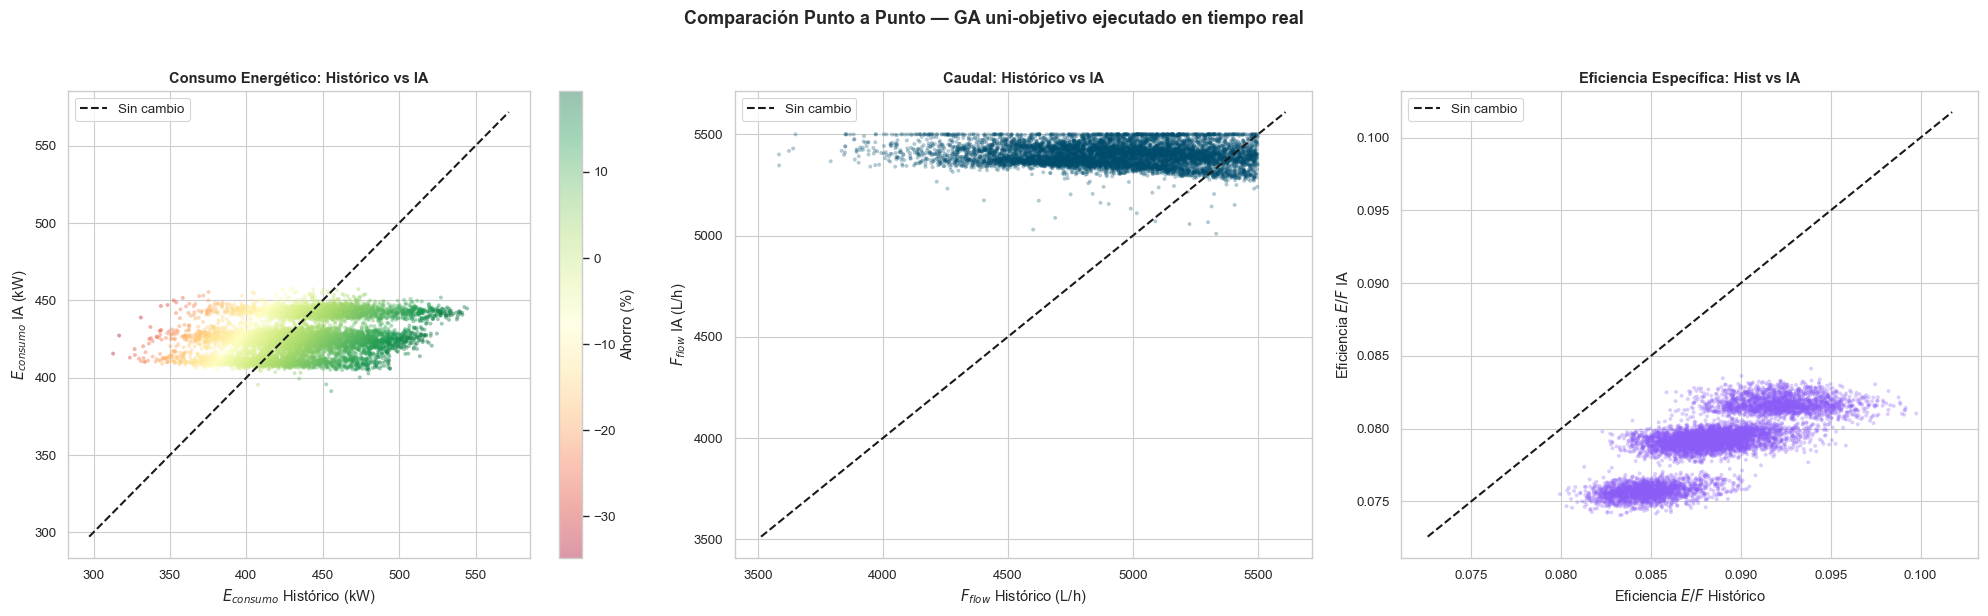

In [9]:
# ==============================================================================
# 6.2 SCATTER: Histórico vs IA punto a punto
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 6.2.1 E_consumo ---
max_e = max(df_eval['HIST_E_consumo'].max(), df_eval['IA_E_consumo'].max()) * 1.05
min_e = min(df_eval['HIST_E_consumo'].min(), df_eval['IA_E_consumo'].min()) * 0.95

scatter = axes[0].scatter(df_eval['HIST_E_consumo'], df_eval['IA_E_consumo'],
                          c=df_eval['Ahorro_pct'], cmap='RdYlGn', alpha=0.4, s=8, edgecolors='none')
axes[0].plot([min_e, max_e], [min_e, max_e], 'k--', linewidth=1.5, label='Sin cambio')
axes[0].set_xlabel('$E_{consumo}$ Histórico (kW)')
axes[0].set_ylabel('$E_{consumo}$ IA (kW)')
axes[0].set_title('Consumo Energético: Histórico vs IA', fontweight='bold')
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label='Ahorro (%)')

# --- 6.2.2 F_flow ---
max_f = max(df_eval['HIST_F_flow'].max(), df_eval['IA_F_flow'].max()) * 1.02
min_f = min(df_eval['HIST_F_flow'].min(), df_eval['IA_F_flow'].min()) * 0.98

axes[1].scatter(df_eval['HIST_F_flow'], df_eval['IA_F_flow'],
                c='#004c6d', alpha=0.3, s=8, edgecolors='none')
axes[1].plot([min_f, max_f], [min_f, max_f], 'k--', linewidth=1.5, label='Sin cambio')
axes[1].set_xlabel('$F_{flow}$ Histórico (L/h)')
axes[1].set_ylabel('$F_{flow}$ IA (L/h)')
axes[1].set_title('Caudal: Histórico vs IA', fontweight='bold')
axes[1].legend()

# --- 6.2.3 Eficiencia específica ---
max_eff = max(df_eval['HIST_Eficiencia'].max(), df_eval['IA_Eficiencia'].max()) * 1.02
min_eff = min(df_eval['HIST_Eficiencia'].min(), df_eval['IA_Eficiencia'].min()) * 0.98

axes[2].scatter(df_eval['HIST_Eficiencia'], df_eval['IA_Eficiencia'],
                c='#8B5CF6', alpha=0.3, s=8, edgecolors='none')
axes[2].plot([min_eff, max_eff], [min_eff, max_eff], 'k--', linewidth=1.5, label='Sin cambio')
axes[2].set_xlabel('Eficiencia $E/F$ Histórico')
axes[2].set_ylabel('Eficiencia $E/F$ IA')
axes[2].set_title('Eficiencia Específica: Hist vs IA', fontweight='bold')
axes[2].legend()

plt.suptitle('Comparación Punto a Punto — GA uni-objetivo ejecutado en tiempo real',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/images/eval_rt_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

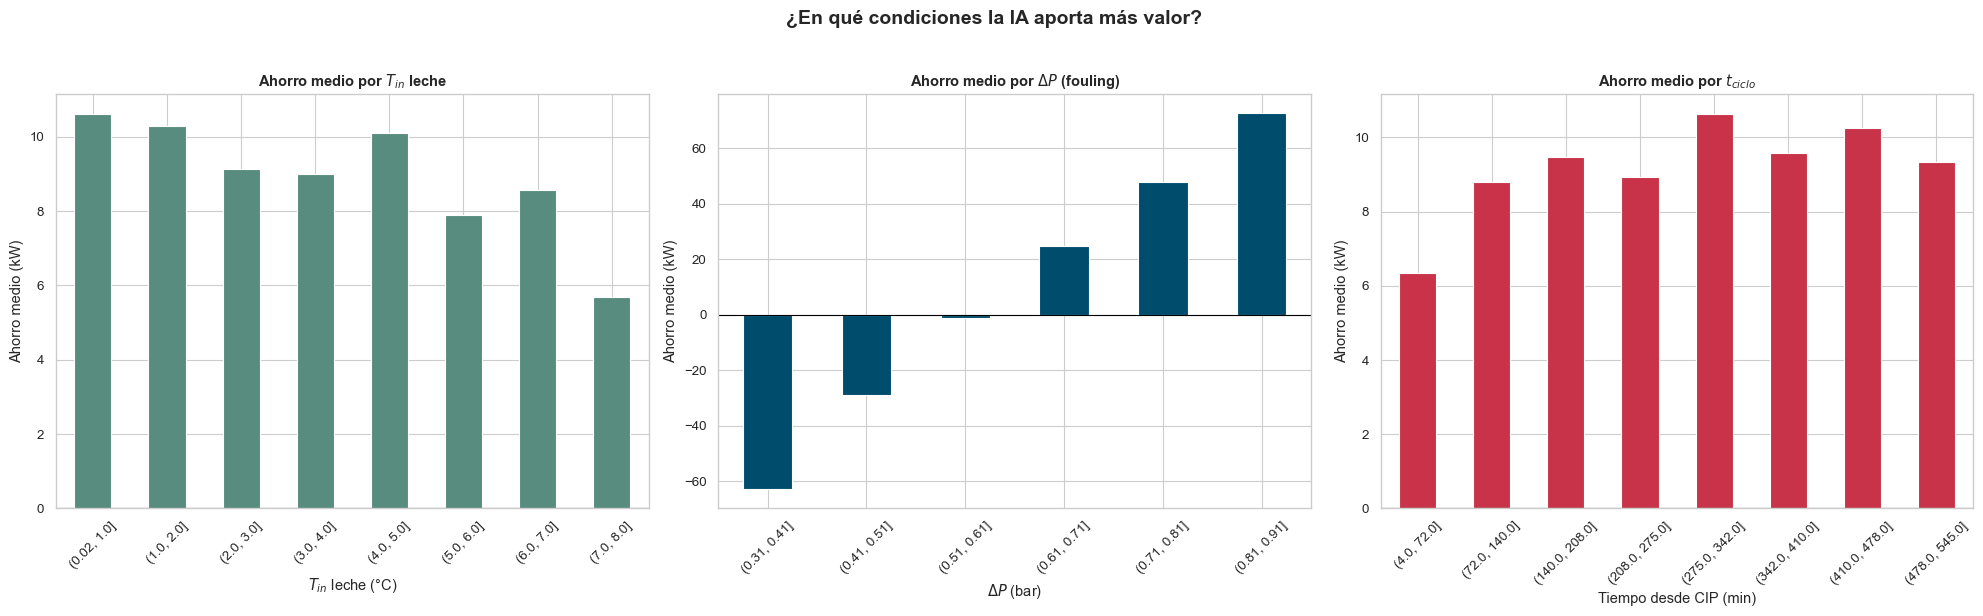

In [10]:
# ==============================================================================
# 6.3 AHORRO SEGMENTADO POR CONDICIONES OPERATIVAS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 6.3.1 Ahorro medio por rango de T_in_leche ---
df_eval['T_in_bin'] = pd.cut(df_eval['T_in_leche'], bins=8, precision=1)
ahorro_por_tin = df_eval.groupby('T_in_bin', observed=True)['Ahorro_kW'].mean()
ahorro_por_tin.plot(kind='bar', ax=axes[0], color='#588c7e', edgecolor='white')
axes[0].set_title('Ahorro medio por $T_{in}$ leche', fontweight='bold')
axes[0].set_xlabel('$T_{in}$ leche (°C)')
axes[0].set_ylabel('Ahorro medio (kW)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0, color='black', linewidth=0.8)

# --- 6.3.2 Ahorro medio por Delta_P ---
df_eval['DP_bin'] = pd.cut(df_eval['Delta_P'], bins=6, precision=2)
ahorro_por_dp = df_eval.groupby('DP_bin', observed=True)['Ahorro_kW'].mean()
ahorro_por_dp.plot(kind='bar', ax=axes[1], color='#004c6d', edgecolor='white')
axes[1].set_title('Ahorro medio por $\Delta P$ (fouling)', fontweight='bold')
axes[1].set_xlabel('$\Delta P$ (bar)')
axes[1].set_ylabel('Ahorro medio (kW)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0, color='black', linewidth=0.8)

# --- 6.3.3 Ahorro medio por t_ciclo ---
df_eval['t_ciclo_bin'] = pd.cut(df_eval['t_ciclo'], bins=8, precision=0)
ahorro_por_tciclo = df_eval.groupby('t_ciclo_bin', observed=True)['Ahorro_kW'].mean()
ahorro_por_tciclo.plot(kind='bar', ax=axes[2], color='#c83349', edgecolor='white')
axes[2].set_title('Ahorro medio por $t_{ciclo}$', fontweight='bold')
axes[2].set_xlabel('Tiempo desde CIP (min)')
axes[2].set_ylabel('Ahorro medio (kW)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(0, color='black', linewidth=0.8)

plt.suptitle('¿En qué condiciones la IA aporta más valor?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/images/eval_rt_ahorro_segmentado.png', dpi=300, bbox_inches='tight')
plt.show()

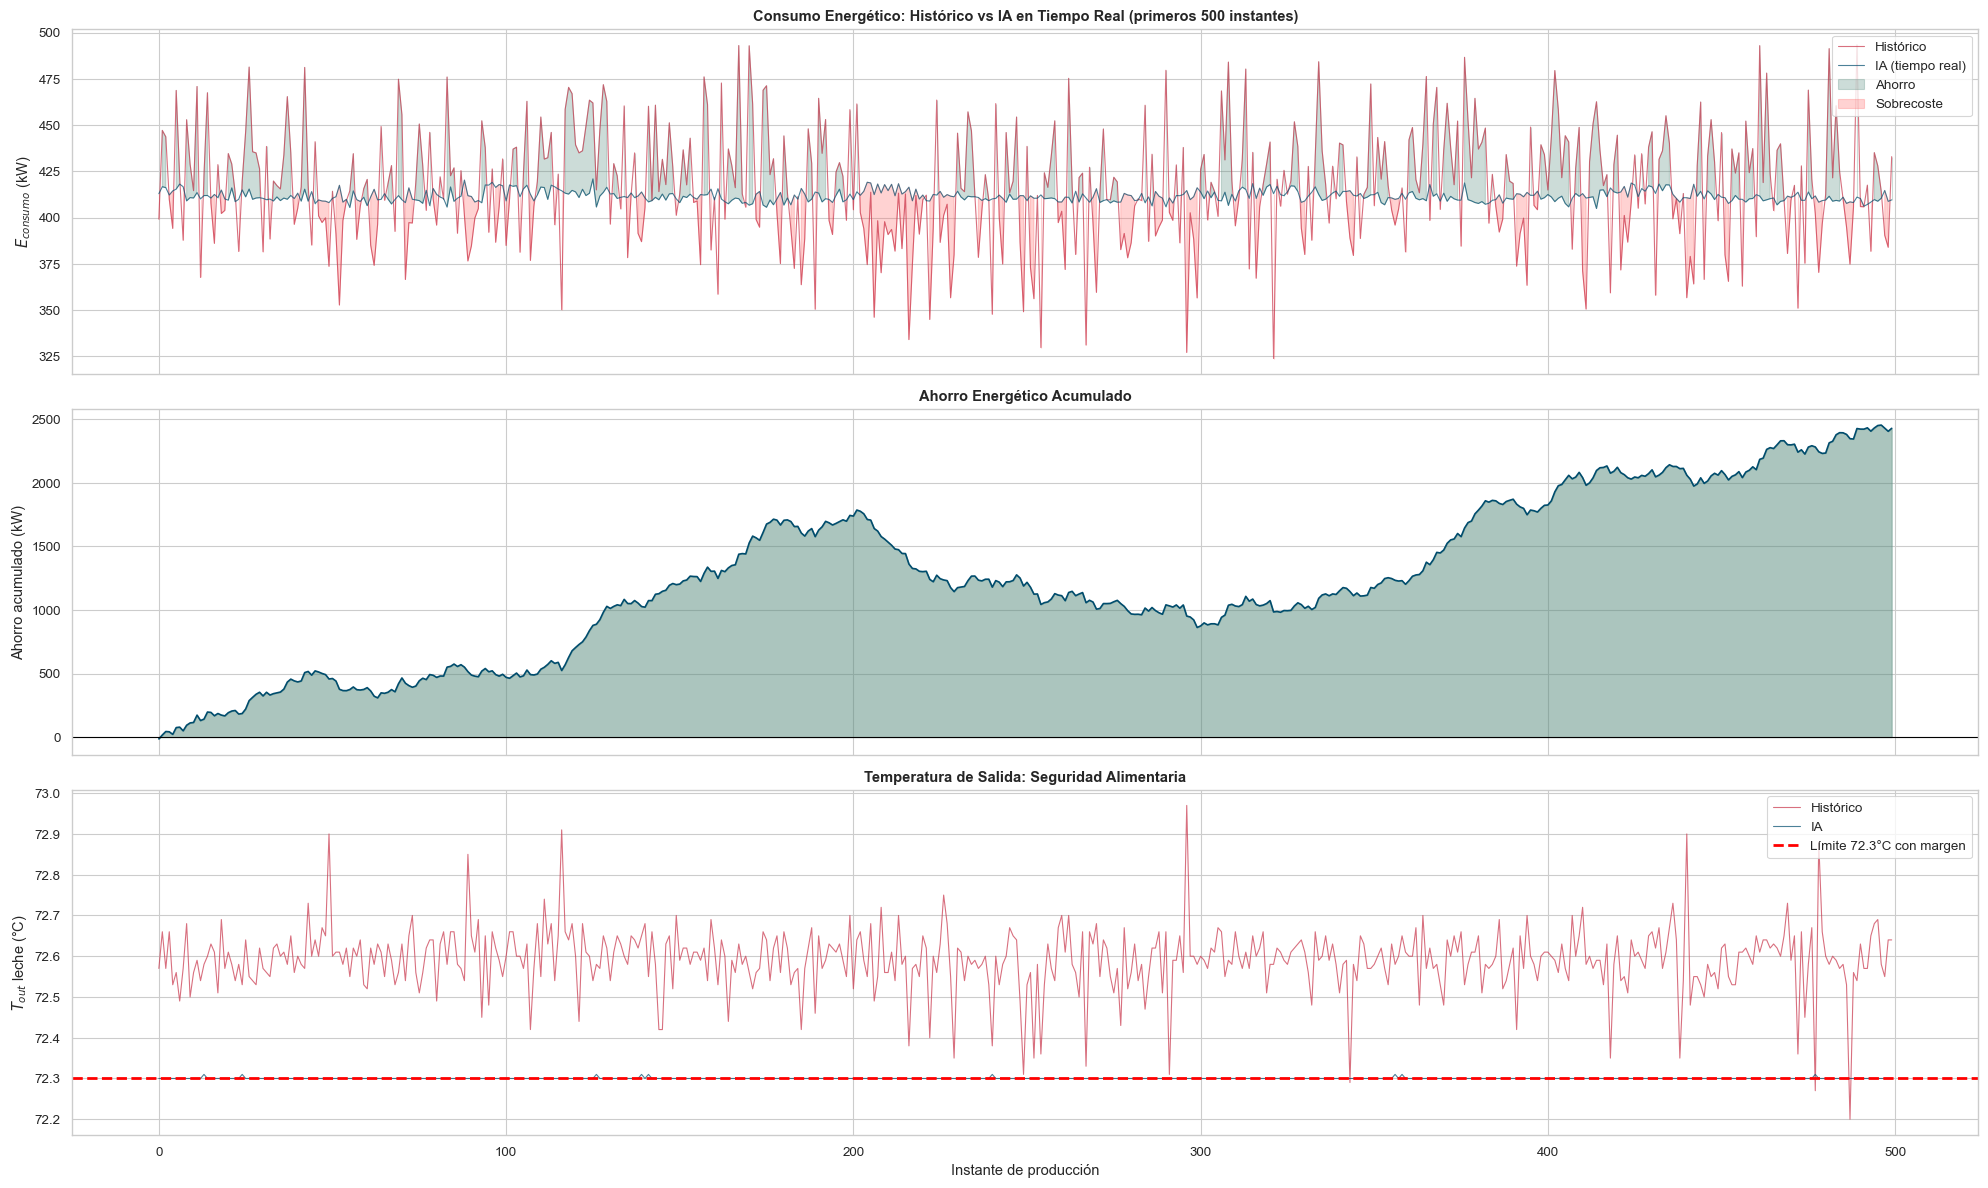

In [11]:
# ==============================================================================
# 6.4 SIMULACIÓN TEMPORAL: Consumo a lo largo de la operación
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

N_PLOT = min(500, len(df_eval))
x = range(N_PLOT)

# --- 6.4.1 Consumo energético en el tiempo ---
axes[0].plot(x, df_eval['HIST_E_consumo'].iloc[:N_PLOT], color='#c83349', alpha=0.7,
             linewidth=0.8, label='Histórico')
axes[0].plot(x, df_eval['IA_E_consumo'].iloc[:N_PLOT], color='#004c6d', alpha=0.7,
             linewidth=0.8, label='IA (tiempo real)')
axes[0].fill_between(x, df_eval['IA_E_consumo'].iloc[:N_PLOT], df_eval['HIST_E_consumo'].iloc[:N_PLOT],
                     where=df_eval['Ahorro_kW'].iloc[:N_PLOT] > 0, alpha=0.3, color='#588c7e', label='Ahorro')
axes[0].fill_between(x, df_eval['IA_E_consumo'].iloc[:N_PLOT], df_eval['HIST_E_consumo'].iloc[:N_PLOT],
                     where=df_eval['Ahorro_kW'].iloc[:N_PLOT] <= 0, alpha=0.3, color='#ff6b6b', label='Sobrecoste')
axes[0].set_ylabel('$E_{consumo}$ (kW)')
axes[0].set_title('Consumo Energético: Histórico vs IA en Tiempo Real (primeros 500 instantes)', fontweight='bold')
axes[0].legend(loc='upper right')

# --- 6.4.2 Ahorro acumulado ---
ahorro_acum = df_eval['Ahorro_kW'].iloc[:N_PLOT].cumsum()
axes[1].fill_between(x, ahorro_acum, alpha=0.5, color='#588c7e')
axes[1].plot(x, ahorro_acum, color='#004c6d', linewidth=1.2)
axes[1].set_ylabel('Ahorro acumulado (kW)')
axes[1].set_title('Ahorro Energético Acumulado', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)

# --- 6.4.3 T_out comparativa ---
axes[2].plot(x, df_eval['HIST_T_out'].iloc[:N_PLOT], color='#c83349', alpha=0.7,
             linewidth=0.8, label='Histórico')
axes[2].plot(x, df_eval['IA_T_out'].iloc[:N_PLOT], color='#004c6d', alpha=0.7,
             linewidth=0.8, label='IA')
axes[2].axhline(72.3, color='red', linestyle='--', linewidth=2, label='Límite 72.3°C con margen')
axes[2].set_ylabel('$T_{out}$ leche (°C)')
axes[2].set_xlabel('Instante de producción')
axes[2].set_title('Temperatura de Salida: Seguridad Alimentaria', fontweight='bold')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.savefig('../../data/images/eval_rt_simulacion_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Resumen Ejecutivo y Guardado de Artefactos



Generamos un informe JSON con todas las métricas del backtesting en tiempo real y exportamos el dataframe de evaluación completo.



**Artefactos generados:**

- `data/predictions/evaluation_rt_hist_vs_ia.csv` — Evaluación punto a punto

- `models/metrics/evaluation_rt_backtesting_report.json` — Reporte técnico

- `data/images/eval_rt_*.png` — Visualizaciones

In [12]:
# ==============================================================================
# 7. RESUMEN EJECUTIVO Y GUARDADO DE ARTEFACTOS
# ==============================================================================
import json

# --- Reporte de evaluación ---
eval_report = {
    "version": "v4",
    "descripcion": "Backtesting en tiempo real: GA uni-objetivo ejecutado sobre cada instancia de test",
    "metodologia": "GA uni-objetivo (150 ind × 15 gen) — min E/F — HallOfFame(1)",
    "datos": {
        "n_instancias_test": int(len(df_eval)),
        "pct_factibles": round(float(df_eval['IA_factible'].mean() * 100), 2),
        "tiempo_total_s": round(t_total, 1),
        "tiempo_medio_ms": round(t_total / len(df_eval) * 1000, 1),
    },
    "kpi_energia": {
        "E_consumo_hist_medio_kW": round(float(E_hist_media), 2),
        "E_consumo_ia_medio_kW": round(float(E_ia_media), 2),
        "ahorro_medio_kW": round(float(ahorro_medio_kw), 2),
        "ahorro_medio_pct": round(float(ahorro_medio_pct), 2),
        "ahorro_total_kW": round(float(ahorro_total_kw), 1),
    },
    "kpi_eficiencia_especifica": {
        "E_F_hist_medio": round(float(eff_hist_media), 6),
        "E_F_ia_medio": round(float(eff_ia_media), 6),
        "mejora_absoluta": round(float(mejora_eff_media), 6),
        "mejora_pct": round(float(mejora_eff_pct), 2),
    },
    "kpi_produccion": {
        "F_flow_hist_medio_Lh": round(float(F_hist_media), 1),
        "F_flow_ia_medio_Lh": round(float(F_ia_media), 1),
        "delta_F_flow_medio": round(float(delta_F_medio), 1),
        "delta_F_flow_pct": round(float(delta_F_pct), 2),
    },
    "kpi_seguridad": {
        "cumplimiento_hist_pct": round(float(cumplimiento_hist), 2),
        "cumplimiento_ia_pct": round(float(cumplimiento_ia), 2),
        "T_out_ia_min": round(float(T_out_ia_min), 2),
        "T_out_ia_medio": round(float(T_out_ia_media), 2),
    },
    "kpi_T_servicio": {
        "T_serv_hist_medio": round(float(T_serv_hist_media), 2),
        "T_serv_ia_medio": round(float(T_serv_ia_media), 2),
        "delta_T_servicio": round(float(delta_T_serv), 2),
    },
}

# --- Guardar reporte JSON ---
REPORT_PATH = "../../models/metrics/evaluation_rt_backtesting_report.json"
with open(REPORT_PATH, 'w') as f:
    json.dump(eval_report, f, indent=4, ensure_ascii=False)

# --- Guardar CSV de evaluación ---
EVAL_CSV_PATH = "../../data/predictions/evaluation_rt_hist_vs_ia.csv"
cols_export = [
    'T_in_leche', 'Delta_P', 't_ciclo',
    'HIST_F_flow', 'HIST_T_servicio', 'HIST_E_consumo', 'HIST_T_out',
    'IA_F_flow', 'IA_T_servicio', 'IA_E_consumo', 'IA_T_out', 'IA_factible',
    'IA_consumo_especifico', 'fitness_final',
    'Ahorro_kW', 'Ahorro_pct', 'HIST_Eficiencia', 'IA_Eficiencia', 'Mejora_Eficiencia',
]
df_eval[cols_export].to_csv(EVAL_CSV_PATH, index=False)

# --- Resumen ejecutivo ---
print("=" * 70)
print("📋 RESUMEN EJECUTIVO — BACKTESTING EN TIEMPO REAL (V4 UNI-OBJETIVO)")
print("=" * 70)

print(f"\n🔬 BASE DE EVALUACIÓN")
print(f"   Instancias de test optimizadas:   {len(df_eval):,}")
print(f"   Soluciones factibles:             {df_eval['IA_factible'].sum():,} ({df_eval['IA_factible'].mean()*100:.1f}%)")
print(f"   Tiempo total:                     {t_total:.1f}s ({t_total/60:.1f} min)")
print(f"   Velocidad:                        {len(df_eval)/t_total:.0f} inst/s | {t_total/len(df_eval)*1000:.1f} ms/inst")

print(f"\n⚡ IMPACTO ENERGÉTICO")
print(f"   Ahorro medio:        {ahorro_medio_kw:+.2f} kW/instante ({ahorro_medio_pct:+.2f}%)")
print(f"   Ahorro total test:   {ahorro_total_kw:+,.1f} kW acumulados")

print(f"\n📈 EFICIENCIA OPERATIVA")
print(f"   Eficiencia hist:     {eff_hist_media:.6f} kW/(L/h)")
print(f"   Eficiencia IA:       {eff_ia_media:.6f} kW/(L/h)")
print(f"   Mejora:              {mejora_eff_pct:+.2f}%")

print(f"\n🏭 PRODUCCIÓN")
print(f"   F_flow hist/IA:      {F_hist_media:.0f} / {F_ia_media:.0f} L/h ({delta_F_pct:+.1f}%)")

print(f"\n🔒 SEGURIDAD ALIMENTARIA")
print(f"   T_out ≥ 72.3°C hist:   {cumplimiento_hist:.1f}%")
print(f"   T_out ≥ 72.3°C IA:     {cumplimiento_ia:.1f}%")
print(f"   T_out mínimo IA:     {T_out_ia_min:.2f} °C")

print(f"\n💾 ARTEFACTOS GUARDADOS")
print(f"   → {REPORT_PATH}")
print(f"   → {EVAL_CSV_PATH}")
print("=" * 70)

📋 RESUMEN EJECUTIVO — BACKTESTING EN TIEMPO REAL (V4 UNI-OBJETIVO)

🔬 BASE DE EVALUACIÓN
   Instancias de test optimizadas:   7,708
   Soluciones factibles:             7,708 (100.0%)
   Tiempo total:                     5220.1s (87.0 min)
   Velocidad:                        1 inst/s | 677.2 ms/inst

⚡ IMPACTO ENERGÉTICO
   Ahorro medio:        +9.14 kW/instante (+1.48%)
   Ahorro total test:   +70,416.5 kW acumulados

📈 EFICIENCIA OPERATIVA
   Eficiencia hist:     0.088448 kW/(L/h)
   Eficiencia IA:       0.078960 kW/(L/h)
   Mejora:              +10.73%

🏭 PRODUCCIÓN
   F_flow hist/IA:      4921 / 5399 L/h (+9.7%)

🔒 SEGURIDAD ALIMENTARIA
   T_out ≥ 72.3°C hist:   99.4%
   T_out ≥ 72.3°C IA:     100.0%
   T_out mínimo IA:     72.30 °C

💾 ARTEFACTOS GUARDADOS
   → ../../models/metrics/evaluation_rt_backtesting_report.json
   → ../../data/predictions/evaluation_rt_hist_vs_ia.csv
